## Übung 2 - Explorative Datenanalyse

#### Aufgabe 1: Python besser kennenlernen (5)

Lesen Sie den Datensatz _citywealth.dat_ in Python ein. Versuchen Sie den Datensatz zu verstehen, er enthält geschätzte Vermögen der Bewohner mehrerer Kleinstädte.

In [17]:
import pandas as pd
citywealth = pd.read_csv("citywealth.dat", sep=" ")
citywealth

,GreenMountain,ForrestHill,BadHumbug,CommunistCommune,FairCity
0,101878,141036,987419.0,100000.0,169933
1,59424,124963,935132.0,100000.0,181228
2,92580,116072,995132.0,100000.0,8243
3,102741,128039,985461.0,100000.0,170675
4,102170,107133,1003128.0,100000.0,76163
...,...,...,...,...,...
2995,84282,137929,953249.0,100000.0,48275
2996,109705,91237,962419.0,100000.0,15422
2997,86151,101122,989996.0,100000.0,111311
2998,98332,113566,987565.0,100000.0,126941


__a)__
Lassen Sie sich mit `describe()` die wichtigsten Kenngrößen anzeigen - welche Gemeinsamkeiten und Unterschiede stellen Sie fest?

In [3]:
citywealth.describe()

,GreenMountain,ForrestHill,BadHumbug,CommunistCommune,FairCity
count,3000.000000,3000.000000,3.000000e+03,3000.0,3000.000000
mean,100047.938333,100923.546000,4.313481e+06,100000.0,101113.322333
std,20221.632501,20193.187487,1.825563e+08,0.0,57527.418772
min,25389.000000,38426.000000,9.104170e+05,100000.0,34.000000
25%,86454.750000,87342.250000,9.668325e+05,100000.0,50033.500000
50%,99872.000000,100756.000000,9.799850e+05,100000.0,102106.000000
75%,114109.500000,114546.750000,9.947925e+05,100000.0,149854.000000
max,181002.000000,180284.000000,1.000000e+10,100000.0,199941.000000


Datenmengen sind Unterschiedlich.
Bei BadHumbug weicht Median stark vom aretmetischen Mittel ab. Evt Starke ausreißer?
std also Standartabweichung sehr hoch in Bad Humbug.
Evt sind die Daten in BadHumbug tatsächlich Humbug.

Communist city evt fälschung weil alle sgenau gleich.


__b)__
Visualisieren Sie die Verteilungen je Stadt durch ein Histogramm und vergleichend im Boxplot.  

In [2]:
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

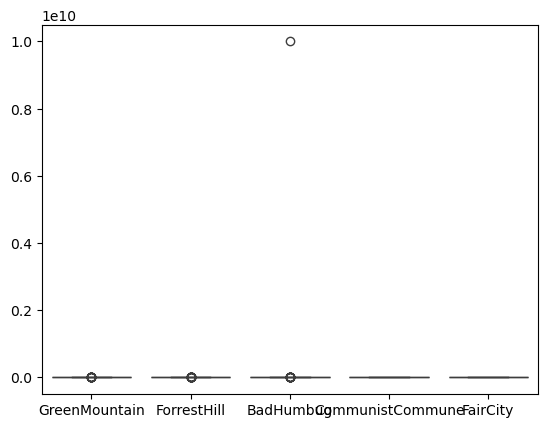

In [5]:
sns.boxplot(data=citywealth)
plt.show()

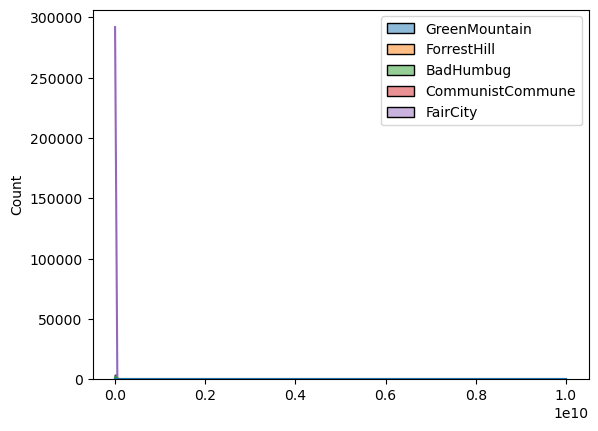

In [7]:
sns.histplot(data=citywealth, kde=True)
plt.show()

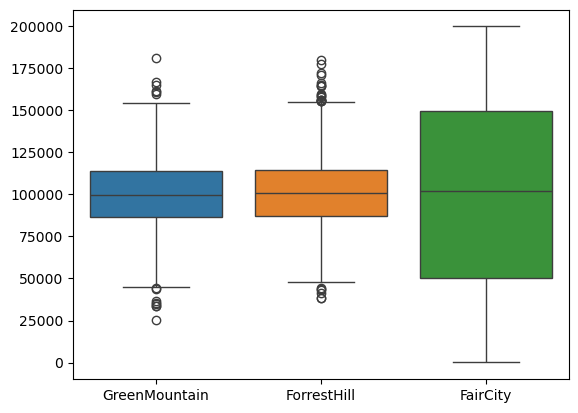

In [10]:
sns.boxplot(data=citywealth.drop(columns=["BadHumbug", "CommunistCommune"]))
plt.show()

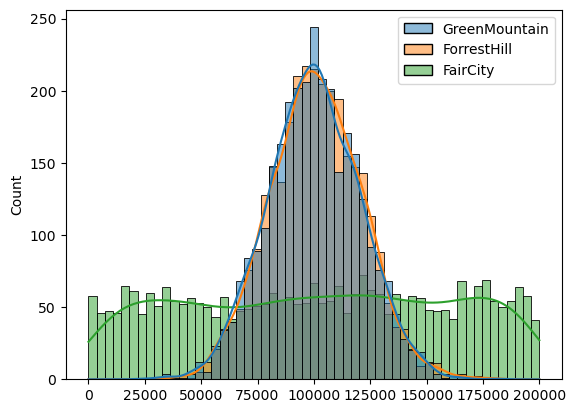

In [12]:
sns.histplot(data=citywealth.drop(columns=["BadHumbug", "CommunistCommune"]), kde=True)
plt.show()

#### Aufgabe 2: Daten Skalieren (5)

Verwenden Sie die Daten aus Aufgabe 1. 

__a)__ Skalieren Sie die Daten je Stadt mittels z-Score Skalierung. (Hinweis: Bitte ohne die Verwendung eines Python-Scalers)

In [20]:
citywealth = citywealth.drop(columns=["BadHumbug", "CommunistCommune"])
df_Scaliert = (citywealth - citywealth.mean()) / citywealth.std()

__b)__ Lassen Sie sich wieder Histogramm und Boxplots anzeigen, was fällt Ihnen auf?

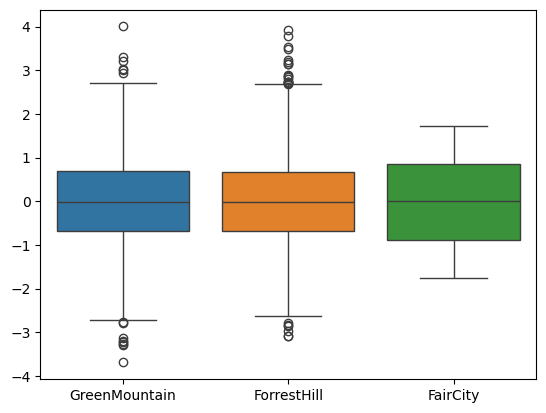

In [21]:
sns.boxplot(data=df_Scaliert)
plt.show()

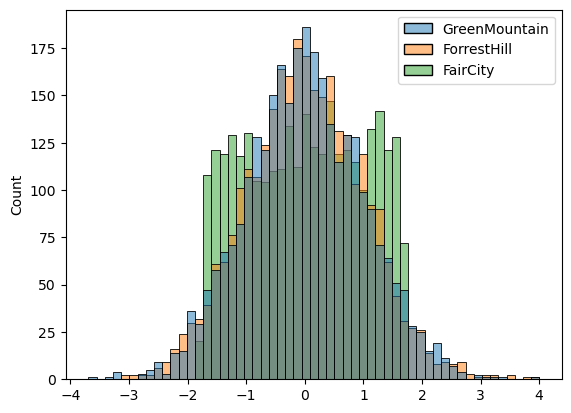

In [22]:
sns.histplot(data=df_Scaliert)
plt.show()

Bei den scalierten Daten hat es den Anschein, dass Fair city eine viel ähnlichere verteilung hat als es tatsächlich der fall ist.
Weil die Standartabweichung größer ist werden die Daten mehr gestaucht.

__c)__ Verwenden Sie nun die min-max Normalisierung (wieder ohne vorgefertigte Pythonbibliotheken).

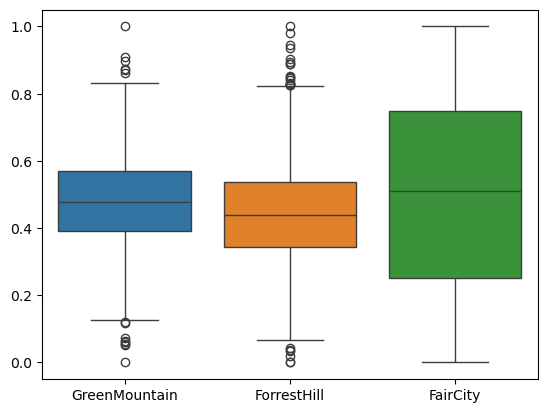

In [24]:
df_Scaliert = (citywealth - citywealth.min()) / (citywealth.max() - citywealth.min())
sns.boxplot(data=df_Scaliert)
plt.show()

__d)__ Erstellen und betrachten sie wieder Boxplots und Histogramme. Was fällt Ihnen auf?

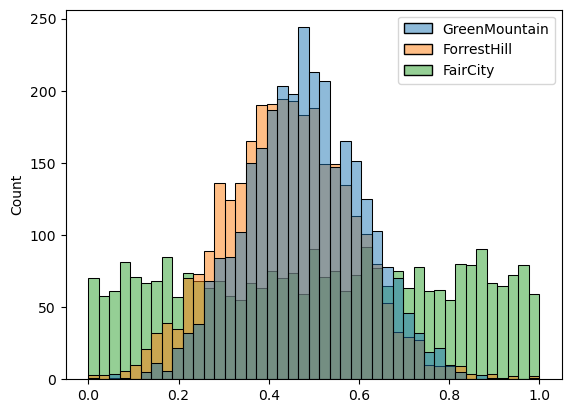

In [25]:
sns.histplot(data=df_Scaliert)
plt.show()

Beim Boxplot fällt nun auf das dir Werte von Green Mountain höher liegen als bei Forest Hill.

### Aufgabe 3: Verteilungen anpassen (5)

Erstellen Sie die gegebenen fünf Verteilungen:

In [19]:
import numpy as np

In [26]:
dist_a=np.random.normal(loc=0.0, scale=1.0, size=1000)
dist_b=np.random.normal(loc=50, scale=3, size =1000)
dist_c=np.random.uniform(low=20,high=50,size=1000)
dist_d=np.random.uniform(low=10,high=100,size=1000)
dist_e = np.random.exponential(1.5, 1000)

__a)__ Lassen Sie sich alle Verteilungen als Boxplot und Histogramm anzeigen

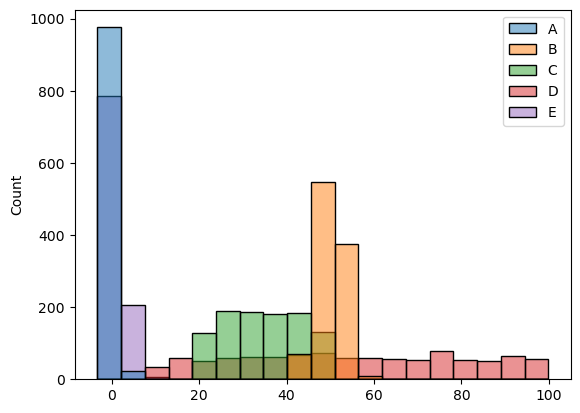

In [36]:
df = pd.DataFrame({
    "A": dist_a,
    "B": dist_b,
    "C": dist_c,
    "D": dist_d,
    "E": dist_e
})
sns.histplot(data=df)
plt.show()

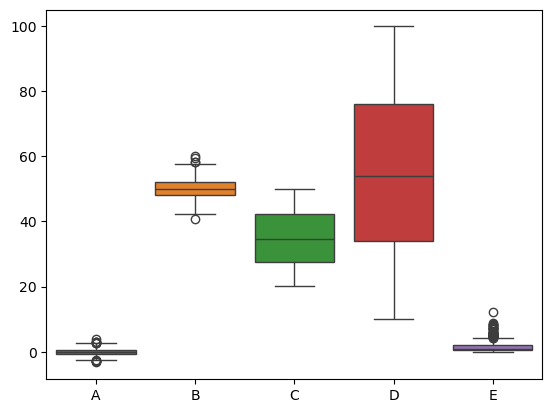

In [29]:
sns.boxplot(data=df)
plt.show()

__b)__ Lassen Sie sich QQ-Plots für alle Paare an Verteilungen anzeigen.

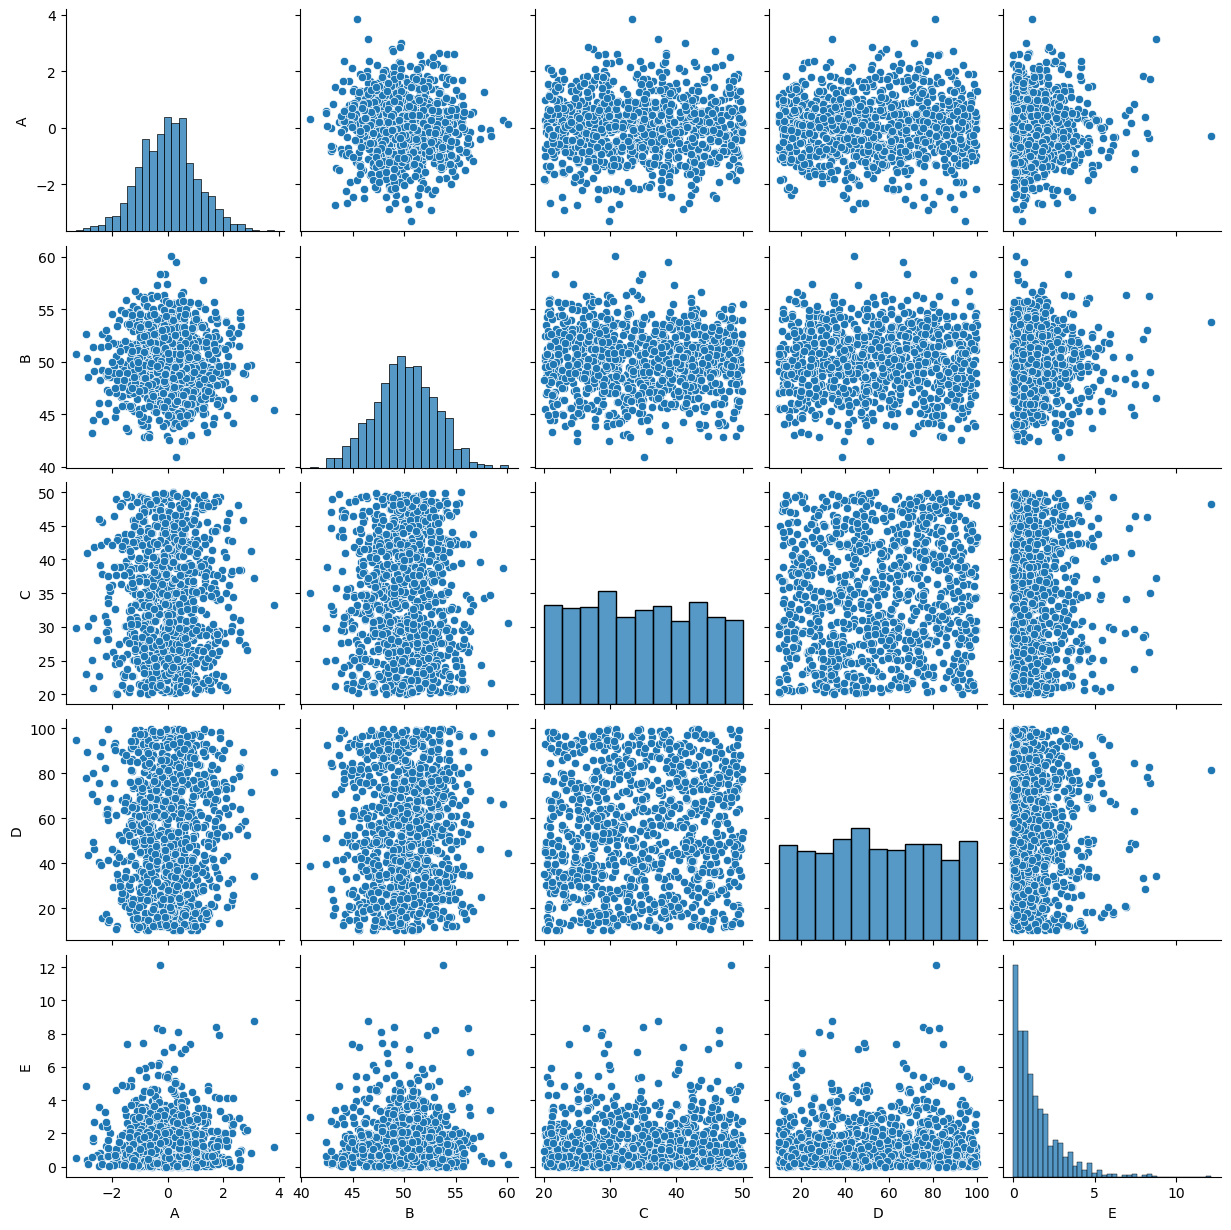

,A,B,C,D,E
0,-0.558875,48.926407,34.155862,12.676454,3.924391
1,-0.735537,51.512298,36.352421,95.917208,0.938333
2,0.268609,51.292039,21.584444,64.365162,0.186112
3,0.910113,49.325046,29.398044,74.221327,0.637576
4,-0.760638,55.299079,48.397493,97.392649,0.268173
...,...,...,...,...,...
995,0.619514,54.531886,20.925851,55.906497,0.235438
996,-0.366393,49.596451,42.355972,41.035077,0.199588
997,-0.472461,54.578572,32.702704,60.795281,3.669770
998,1.038434,54.034575,29.517950,58.045602,0.004452


In [39]:
sns.pairplot(df)
plt.show()
df

__c)__ Führen Sie eine min-max-Skalierung auf den Daten aus und lassen Sie sich erneut Boxplots und Histogramme anzeigen. (Auch wenn es möglich wäre, verwenden Sie hierfür bitte nicht fertige Methoden wie den `MinMaxScaler` - Sie können aber im Anschluss mit ihm vergleichen)

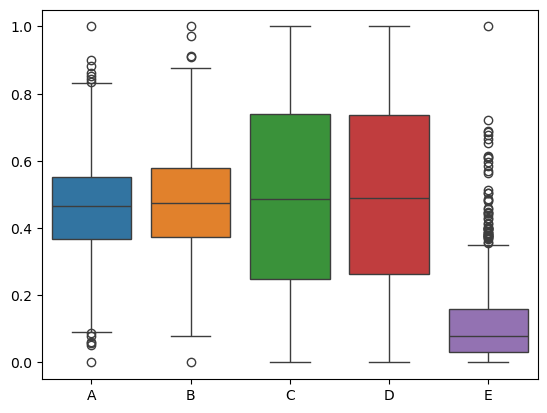

In [40]:
df_min_max = (df - df.min()) / (df.max() - df.min())
sns.boxplot(data=df_min_max)
plt.show()

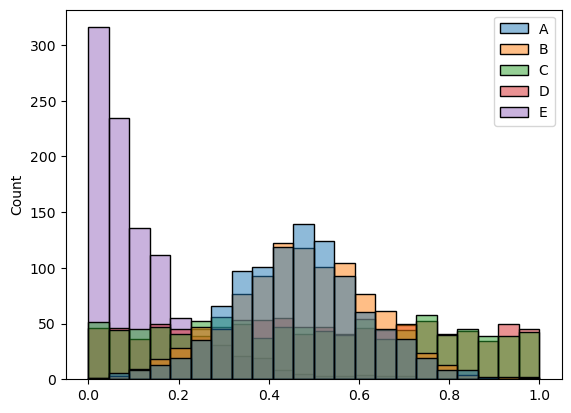

In [41]:
sns.histplot(data=df_min_max)
plt.show()

__d)__ Erstellen Sie für die min-max-Skalierten Werte QQ-Plots. 

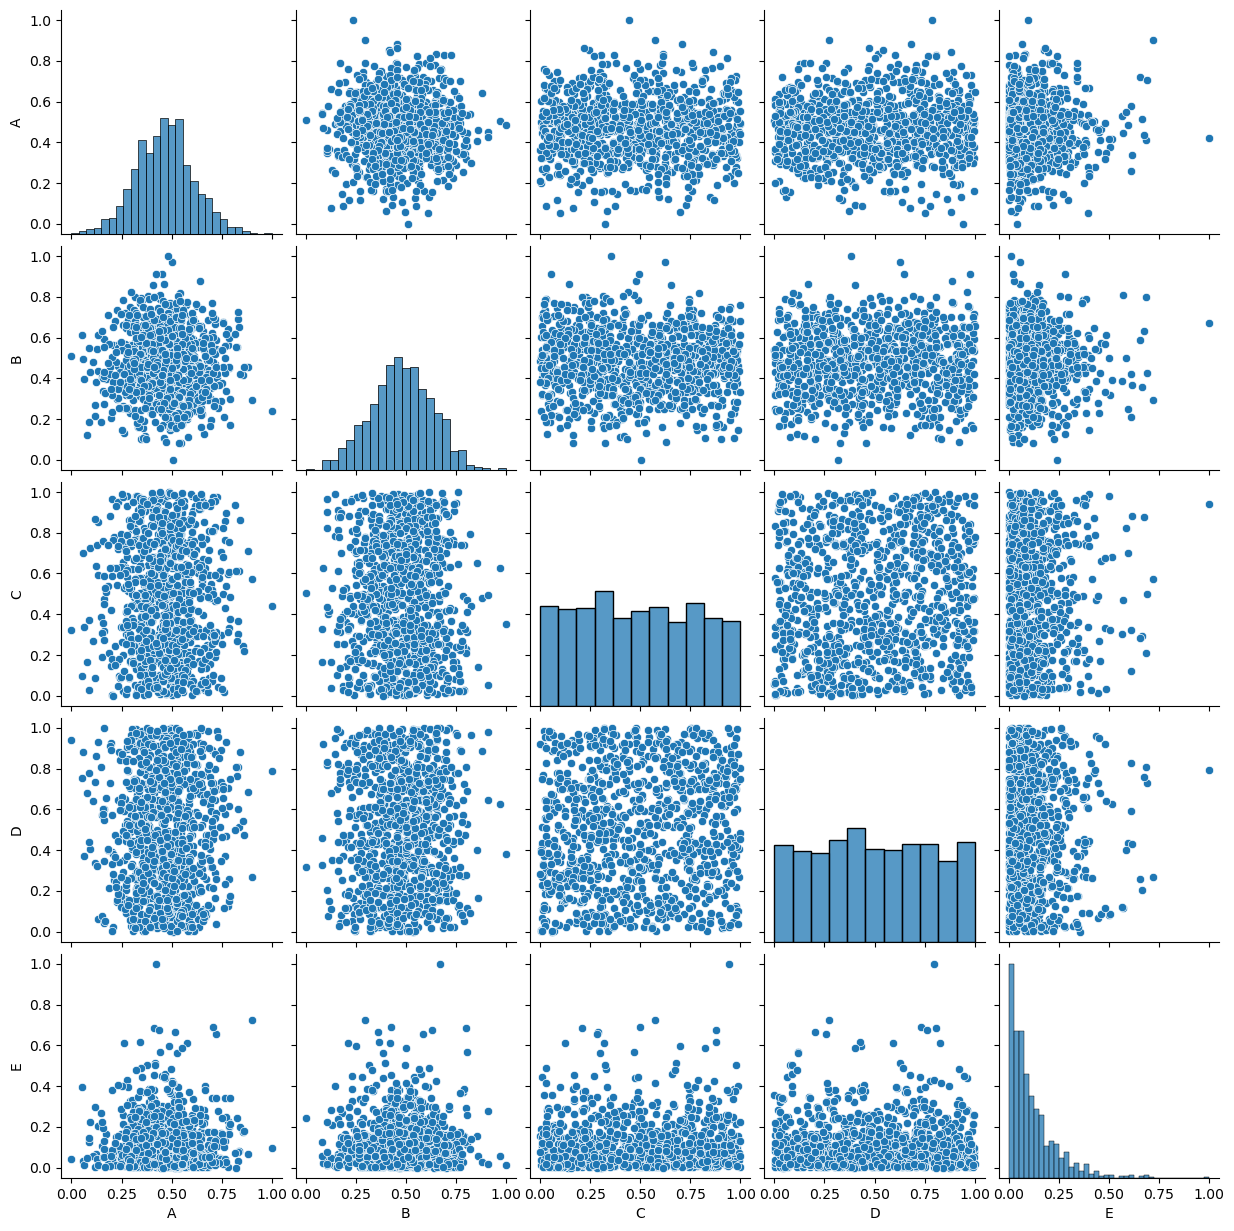

In [42]:
sns.pairplot(df_min_max)
plt.show()

__e)__ Erklären Sie die Ergebnisse.

Im Histogramm und auch im Boxplot sieht man sehr gut die relative verteilung der Werte.
Die QQ plots sind unverändert da sich die relation der Daten zueinander durch die Skalierung nicht ändert.

### Aufgabe 4: Skatterplots (5)

__a)__
Lesen Sie den Datensatz _Kommissare.dat_ in Phyton ein und speichern Sie ihn unter dem Objekt `kommissare`.

In [48]:
kommissare = pd.read_csv("kommissare.dat", sep="\s+")
kommissare

,Name,Beruf,Einkommen,Kontostand,Alter,Kreditklasse
0,Leitmayr,Bauarbeiter,2000,5000,25,schlecht
1,Batic,Rentner,4500,17000,75,schlecht
2,Thiel,Kommissar,4000,9000,52,gut
3,Boerne,Arzt,8000,145000,48,gut
4,Stark,arbeitslos,600,900,37,schlecht
5,Ritter,Informatiker,5000,8000,29,gut
6,Schenk,Unternehmer,18000,271000,53,gut
7,Ballauf,Briefträger,2000,4500,49,schlecht


__b)__
Visualisieren Sie die Attribute _Einkommen_, _Konstostand_ und _Alter_ in einem 3D-Scatterplot (Tipp: mpl_toolkits.mplot3d Axes3D) und einem `pairplot` (Tipp: seaborn). Färben Sie jeweils nach der Spalte Kreditklasse - was fällt Ihnen auf?

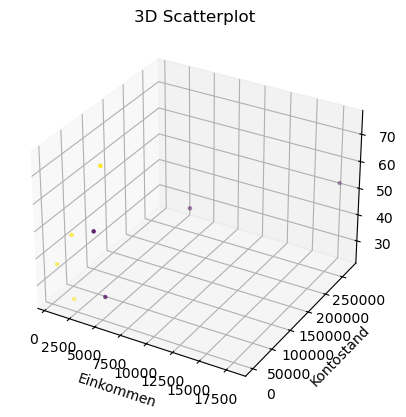

In [59]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(
    kommissare["Einkommen"], 
    kommissare["Kontostand"],
    kommissare["Alter"],
    c=kommissare["Kreditklasse"].astype("category").cat.codes,
    marker='.'
)
ax.set_title("3D Scatterplot")
ax.set_xlabel("Einkommen")
ax.set_ylabel("Kontostand")
ax.set_zlabel("Alter")

plt.show()

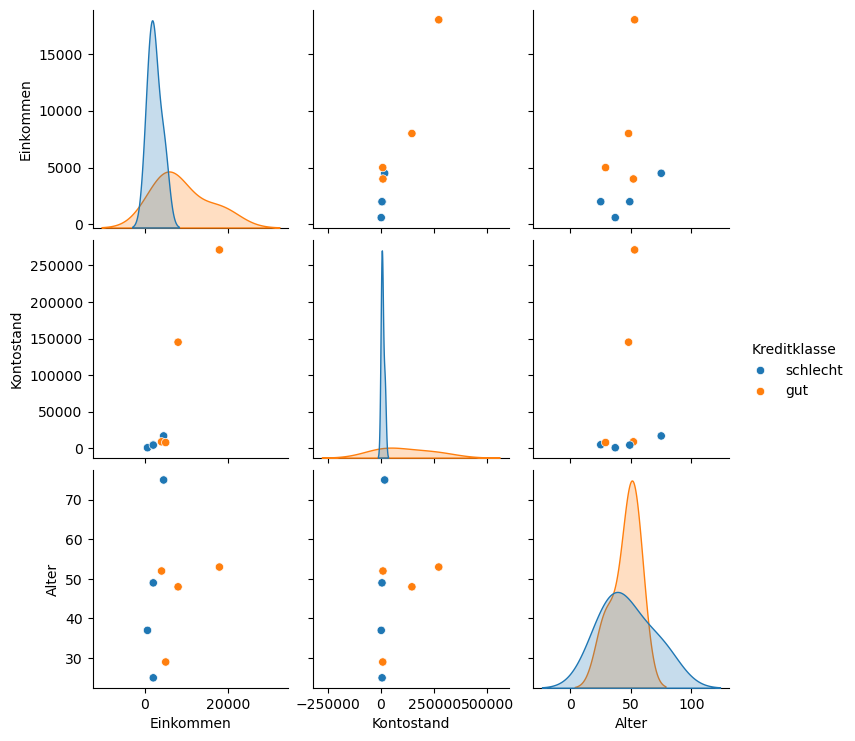

In [61]:
sns.pairplot(kommissare, hue="Kreditklasse")
plt.show()

__c)__
Führen Sie den unteren Code aus - stimmen die Regeln überein mit Ihren Beobachtungen?

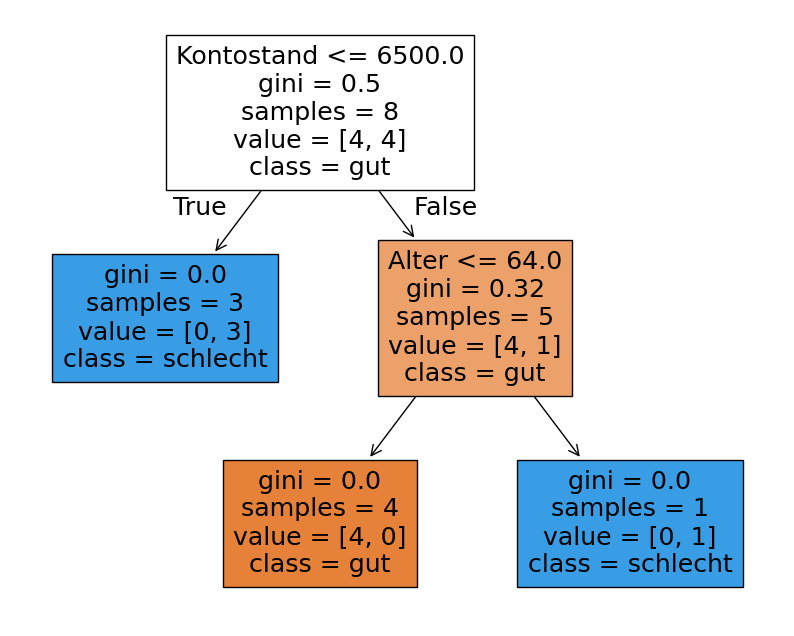

In [62]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import matplotlib.pyplot as plt

# Unabhängige Variablen (Features) und abhängige Variable (Ziel)
X_part = kommissare[["Einkommen","Kontostand","Alter"]]
y_part = kommissare[["Kreditklasse"]]

# Aufteilen in Trainings- und Testdaten

# Erstellen und Trainieren des Entscheidungsbaums
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_part, y_part)

# Visualisieren des Entscheidungsbaums
plt.figure(figsize=(10, 8))
tree.plot_tree(clf, feature_names=["Einkommen","Kontostand","Alter"], class_names=["gut","schlecht"], filled=True)
plt.show()



Nein hier wird nur nach Kontostand und Alter entschieden wärend oben das Einkommen eine wichtige rolle zu spielen scheint.